# Q5 Regression Pipeline (Batch Normalize 후 Regression)

## 목적
- Batch effect 제거 (batch normalization)
- Stable feature로 regression 수행
- RMSE 평가

이 notebook은 **EDA 이후 Modeling 단계**입니다.
Batch normalize는 Feature Engineering + Data Preprocessing 단계에 해당합니다.


## 1. 필요한 라이브러리 import

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score


## 2. Feature 선택

EDA에서 안정적이었던 feature만 사용


In [25]:
features = [
'charge_time_mean',
'QDischarge_delta',
'IR_delta',
'IR_mean'
]

target = 'cycle_life'


## 3. Batch Normalize (핵심 단계)

Batch별 평균/표준편차로 normalize
논문에서도 batch effect 제거가 중요


In [26]:
df1 = pd.read_csv("../results/batch1_features.csv")

df2 = pd.read_csv("../results/batch2_features.csv")

df3 = pd.read_csv("../results/batch3_features.csv")

In [27]:
df1['batch']='B1'
df2['batch']='B2'
df3['batch']='B3'

In [28]:
df_all = pd.concat([df1,df2,df3])

In [29]:
df_all = df_all.dropna(subset=['cycle_life'])

df_all = df_all[df_all['Tmax_mean'] < 80]

In [30]:
def batch_normalize(df):

    df_norm = df.copy()

    cols = features   # feature만!

    df_norm[cols] = df.groupby('batch')[cols].transform(

        lambda x:(x-x.mean())/(x.std()+1e-8)

    )

    return df_norm

## 4. Train/Test split

In [31]:
df_norm = batch_normalize(df_all)

In [ ]:
# X = df_norm[features]

# y = df_norm[target]

# X_train,X_test,y_train,y_test = train_test_split(

#     X,y,test_size=0.2,random_state=42

# )


In [32]:
# ===== Batch based split =====

train_df = df_norm[df_norm['batch']!='B3']

test_df = df_norm[df_norm['batch']=='B3']


X_train = train_df[features]

y_train = train_df[target]


X_test = test_df[features]

y_test = test_df[target]


print("Train size:",len(X_train))

print("Test size:",len(X_test))

Train size: 85
Test size: 44


## 5. Linear Regression

In [33]:
df_all[df_all['cycle_life'].isna()]

,cycle_life,IR_mean,QDischarge_mean,Tmax_mean,Tavg_mean,charge_time_mean,IR_delta,QDischarge_delta,IR_delta_100_10,QDischarge_delta_100_10,IR_var,QDischarge_var,batch


In [34]:
df_norm.isna().sum()

cycle_life                 0
IR_mean                    0
QDischarge_mean            0
Tmax_mean                  0
Tavg_mean                  0
charge_time_mean           0
IR_delta                   0
QDischarge_delta           0
IR_delta_100_10            0
QDischarge_delta_100_10    0
IR_var                     0
QDischarge_var             0
batch                      0
dtype: int64

In [35]:
df_norm.shape

(129, 13)

In [36]:
lr = LinearRegression()

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test,pred_lr))

print("Linear RMSE:",rmse_lr)


Linear RMSE: 476.22294351198923


In [37]:
mape_lr = np.mean(np.abs((y_test - pred_lr)/y_test))*100

print("Linear MAPE:",mape_lr,"%")

Linear MAPE: 34.491015466106454 %


## 6. Random Forest

In [38]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=7,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test,pred_rf))
print("RF RMSE:",rmse_rf)


RF RMSE: 412.0899435607745


In [39]:
mape_rf = np.mean(np.abs((y_test - pred_rf)/y_test))*100

print("RF MAPE:",mape_rf,"%")

RF MAPE: 22.55138082672536 %


## 7. LightGBM

In [40]:
# ===== Batch based split =====

train_df = df_norm[df_norm['batch']!='B3']

test_df = df_norm[df_norm['batch']=='B3']


X_train = train_df[features]

y_train = train_df[target]


X_test = test_df[features]

y_test = test_df[target]


print("Train size:",len(X_train))

print("Test size:",len(X_test))

Train size: 85
Test size: 44


In [41]:
from lightgbm import LGBMRegressor

lgb = LGBMRegressor(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=4,
    num_leaves=15,
    min_child_samples=5,
    random_state=42
)

lgb.fit(X_train,y_train)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000161 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 117
[LightGBM] [Info] Number of data points in the train set: 85, number of used features: 4
[LightGBM] [Info] Start training from score 716.717647
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

,boosting_type,'gbdt'
,num_leaves,15
,max_depth,4
,learning_rate,0.03
,n_estimators,600
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,5


In [42]:
pred_lgb = lgb.predict(X_test)

rmse_lgb = np.sqrt(mean_squared_error(y_test,pred_lgb))

print("LightGBM RMSE:",rmse_lgb)

LightGBM RMSE: 430.99156936200256


In [43]:
mape_lgb = np.mean(np.abs((y_test - pred_lgb)/y_test))*100

print("LightGBM MAPE:",mape_lgb,"%")

LightGBM MAPE: 23.742207699442357 %


## 8. Feature Importance

In [44]:
importance = pd.Series(

rf.feature_importances_,
index=features

).sort_values(ascending=False)

importance


charge_time_mean    0.527527
IR_mean             0.236636
IR_delta            0.144533
QDischarge_delta    0.091304
dtype: float64

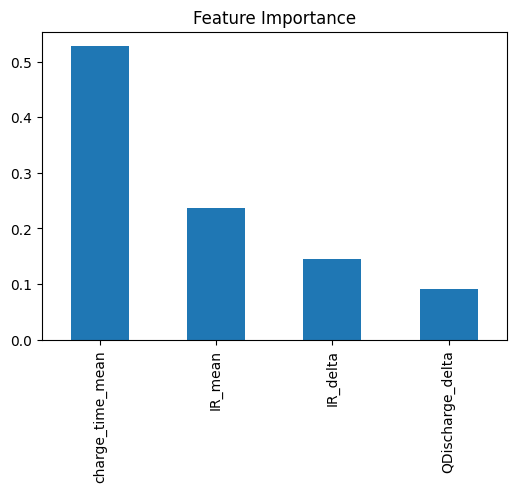

In [45]:
plt.figure(figsize=(6,4))

importance.plot(kind='bar')

plt.title("Feature Importance")

plt.show()


## 9. 실제값 vs 예측값

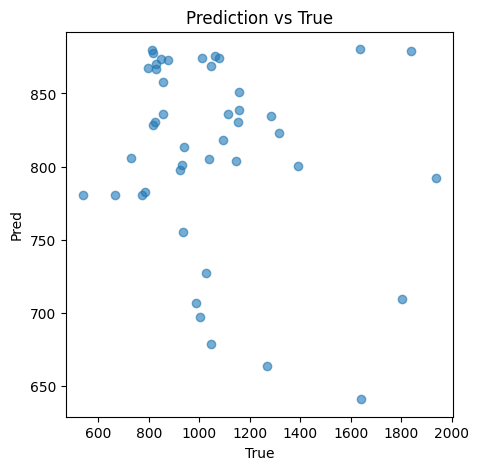

In [46]:
plt.figure(figsize=(5,5))

plt.scatter(y_test,pred_rf,alpha=0.6)

plt.xlabel("True")

plt.ylabel("Pred")

plt.title("Prediction vs True")

plt.show()
